In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os
os.chdir('/content/drive/MyDrive/MLG_Project_Code')

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import math
from typing import List, Tuple, Optional, Dict, Any

In [14]:
# Hyperparameters
STATIC_DIM = 5
TEMPORAL_DIM = 36
TOTAL_DIM = 41
L_IN = 20  # Historical window
L_P = 10   # Prediction window
PATCH_SIZE = 10

In [15]:
class IrregularTimeSeriesDataset(Dataset):
    """Dataset for irregular multivariate time series with static features"""

    def __init__(self, data_list: List[Tuple[str, torch.Tensor, torch.Tensor, torch.Tensor]],
                 seq_len: int = L_IN, pred_len: int = L_P):
        """
        data_list: List of tuples, where each tuple is (ID, timestamps, values, mask)
         - timestamps: (T,) raw times (floats) or -1 for padding
         - values: (T, TOTAL_DIM)
         - mask: (T, TOTAL_DIM) binary
        """
        self.data_list = data_list
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        _, timestamps_raw, values_raw, mask_raw = self.data_list[idx]

        timestamps_raw = timestamps_raw.cpu().float()
        values_raw = values_raw.cpu().float()
        mask_raw = mask_raw.cpu().float()

        # Basic validation
        assert timestamps_raw.ndim == 1
        assert values_raw.ndim == 2
        assert values_raw.shape[-1] == TOTAL_DIM

        total_len = values_raw.shape[0]
        hist_len = self.seq_len
        pred_len = self.pred_len

        # Padding if too short
        if total_len < hist_len + pred_len:
            pad_needed = (hist_len + pred_len) - total_len
            timestamps_raw = F.pad(timestamps_raw, (0, pad_needed), 'constant', -1.0)
            values_raw = F.pad(values_raw, (0, 0, 0, pad_needed), 'constant', 0.0)
            mask_raw = F.pad(mask_raw, (0, 0, 0, pad_needed), 'constant', 0.0)

        # Split
        hist_end = hist_len
        pred_start = hist_len

        X = values_raw[:hist_end]  # (hist_len, TOTAL_DIM)
        truth_time_steps = timestamps_raw[:hist_end]  # (hist_len,)
        mask_hist = mask_raw[:hist_end]  # (hist_len, TOTAL_DIM)

        time_steps_to_predict = timestamps_raw[pred_start:pred_start + pred_len]  # (pred_len,)
        forecast_tgt = values_raw[pred_start:pred_start + pred_len]  # (pred_len, TOTAL_DIM)
        forecast_mask = mask_raw[pred_start:pred_start + pred_len]  # (pred_len, TOTAL_DIM)

        # Normalize timestamps inside the dataset: use min/max of the historical timestamps (ignoring padding -1)
        valid_hist_mask = (truth_time_steps > -0.5)
        if valid_hist_mask.any():
            valid_hist_times = truth_time_steps[valid_hist_mask]
            tmin = valid_hist_times.min()
            tmax = valid_hist_times.max()
            denom = max((tmax - tmin).item(), 0.05)
            if denom < 1e-6:
                denom = 1.0  # all times same -> avoid division by zero
            # normalize history to [0,1]
            truth_time_steps_norm = (truth_time_steps - tmin) / denom
            # normalize future timestamps using same scale (may be >1)
            time_steps_to_predict_norm = (time_steps_to_predict - tmin) / denom
        else:
            # no valid timestamps in history -> set zeros
            truth_time_steps_norm = torch.zeros_like(truth_time_steps)
            time_steps_to_predict_norm = torch.zeros_like(time_steps_to_predict)

        # Expand static features across history for easier processing
        static_features_first_step = X[0, :STATIC_DIM].clone()
        X[:, :STATIC_DIM] = static_features_first_step.unsqueeze(0).expand(hist_len, -1)
        mask_hist[:, :STATIC_DIM] = mask_hist[0, :STATIC_DIM].unsqueeze(0).expand(hist_len, -1)

        # Build last_obs as the full vector (TOTAL_DIM) taken from the last timestep that has ANY observation
        valid_any = (mask_hist.sum(dim=1) > 0).nonzero(as_tuple=False)
        if valid_any.numel() > 0:
            last_valid_t = valid_any.max().item()
            valid = mask_hist[last_valid_t]  # (TOTAL_DIM,)
            last_obs = (X[last_valid_t] * valid)  # zero-out unobserved vars
        else:
            last_obs = torch.zeros(TOTAL_DIM, dtype=X.dtype)

        # Calculate actual history length (non-padded timestamps)
        actual_hist_len = int((truth_time_steps_norm > -0.5).sum().item())

        # Return shapes:
        # X: (hist_len, TOTAL_DIM)
        # truth_time_steps_norm: (hist_len,)
        # mask_hist: (hist_len, TOTAL_DIM)
        # time_steps_to_predict_norm: (pred_len,)
        # last_obs: (TOTAL_DIM,)
        return (X, truth_time_steps_norm, mask_hist, time_steps_to_predict_norm, last_obs), \
               actual_hist_len, \
               forecast_tgt, \
               forecast_mask

# convenience wrapper
def format_data(timestamps_raw, values_raw, mask_raw, seq_len=L_IN, pred_len=L_P):
    dummy_data_list = [("dummy_id", timestamps_raw, values_raw, mask_raw)]
    dataset = IrregularTimeSeriesDataset(dummy_data_list, seq_len, pred_len)
    return dataset[0]

# -----------------------------
# Model components
# -----------------------------
class TimeEmbedding(nn.Module):
    def __init__(self, embedding_dim):
        super(TimeEmbedding, self).__init__()
        self.embedding_dim = embedding_dim
        self.half_dim = self.embedding_dim // 2
        divisor = (self.half_dim - 1) if self.half_dim > 1 else 1.0
        self.inv_freq = torch.exp(torch.arange(self.half_dim, dtype=torch.float32) * -(math.log(10000.0) / divisor))

    def forward(self, t):
        # t can be (seq_len,) or (batch_size, seq_len)
        if t.dim() == 0:
            t = t.unsqueeze(0)
        t_unsqueezed = t.unsqueeze(-1)
        inv_freq_on_device = self.inv_freq.to(t_unsqueezed.device)
        scaled_time = t_unsqueezed * inv_freq_on_device
        emb = torch.cat([torch.sin(scaled_time), torch.cos(scaled_time)], dim=-1)
        if self.embedding_dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb  # (..., embedding_dim)

class GraphAttentionLayer(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.1, alpha=0.2):
        super(GraphAttentionLayer, self).__init__()
        self.W = nn.Linear(in_features, out_features)
        self.a = nn.Linear(2 * out_features, 1)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.a.weight)
        self.leakyrelu = nn.LeakyReLU(alpha)
        self.dropout_layer = nn.Dropout(dropout)

    def forward(self, h, adj):
        Wh = self.W(h)  # (N, out_features)
        N = Wh.size(0)
        Wh_repeated = Wh.unsqueeze(1).expand(-1, N, -1)
        Wh_repeated_transpose = Wh.unsqueeze(0).expand(N, -1, -1)
        concat = torch.cat([Wh_repeated, Wh_repeated_transpose], dim=-1)
        e = self.leakyrelu(self.a(concat).squeeze(-1))
        zero_vec = -9e15 * torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)
        attention = F.softmax(attention, dim=1)
        attention = self.dropout_layer(attention)
        h_prime = torch.matmul(attention, Wh)
        return F.elu(h_prime)

# -----------------------------
# HiPatchVAE (fixed)
# -----------------------------
class HiPatchVAE(nn.Module):
    def __init__(self, static_dim=STATIC_DIM, temporal_dim=TEMPORAL_DIM,
                 hidden_dim=128, latent_dim=64, patch_size=PATCH_SIZE,
                 time_embed_dim=32, dropout=0.1, num_heads=4, seq_len=L_IN):
        super(HiPatchVAE, self).__init__()
        self.static_dim = static_dim
        self.temporal_dim = temporal_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.patch_size = patch_size
        self.time_embed_dim = time_embed_dim
        self.dropout_rate = dropout
        self.seq_len = seq_len

        self.time_embedding = TimeEmbedding(time_embed_dim)

        self.static_encoder = nn.Sequential(
            nn.Linear(static_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4), nn.ReLU(), nn.Dropout(dropout / 2)
        )

        # obs_encoder maps (time_emb + val + var_id_norm) -> hidden
        self.obs_encoder = nn.Sequential(
            nn.Linear(time_embed_dim + 2, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU()
        )

        self.intra_patch_gat = GraphAttentionLayer(hidden_dim, hidden_dim, dropout)
        self.inter_patch_gat = GraphAttentionLayer(hidden_dim, hidden_dim, dropout)  # reserved if needed

        self.multi_head_attn = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)

        # last_obs processing
        self.last_obs_proj = nn.Sequential(
            nn.Linear(static_dim + temporal_dim, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        encoder_output_dim = hidden_dim + hidden_dim // 4 + hidden_dim // 4  # temporal_encoded + static_encoded + last_obs_processed
        self.fc_mu = nn.Linear(encoder_output_dim, latent_dim)
        self.fc_logvar = nn.Linear(encoder_output_dim, latent_dim)

        # Decoder: inputs (z + static_encoded + time_emb) -> temporal_dim
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + hidden_dim // 4 + time_embed_dim, hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, temporal_dim)
        )

        self.forecast_decoder = nn.Sequential(
            nn.Linear(latent_dim + hidden_dim // 4 + time_embed_dim, hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, temporal_dim)
        )

        self.dropout = nn.Dropout(dropout)

    # Single correct definition (no duplicate)
    def _create_patch_embeddings(self, times, values, var_mask):
        """
        times: (num_obs,) normalized times in [0,1] typically (can be >1 for future)
        values: (num_obs, temporal_dim)
        var_mask: (num_obs, temporal_dim) binary
        returns: list of tensors each (1, hidden_dim) for patches (or empty list)
        """
        if len(times) == 0:
            return []

        # clamp times to [0, 1] for patch allocation (ensures stable behavior)
        norm_times = torch.clamp(times, 0.0, 1.0)

        num_patches = self.patch_size
        patch_embeddings = []
        for p in range(num_patches):
            patch_start = p / num_patches
            patch_end = (p + 1) / num_patches
            in_patch = (norm_times >= patch_start) & (norm_times < patch_end)
            if not in_patch.any():
                continue

            patch_times = times[in_patch]
            patch_values = values[in_patch]
            patch_mask = var_mask[in_patch]

            patch_emb = self._encode_patch_observations(patch_times, patch_values, patch_mask)
            if patch_emb is not None:
                patch_embeddings.append(patch_emb.unsqueeze(0))  # (1, hidden_dim)

        return patch_embeddings

    def _encode_patch_observations(self, times, values, var_mask):
        """
        times: (n_obs_in_patch,)
        values: (n_obs_in_patch, temporal_dim)
        var_mask: (n_obs_in_patch, temporal_dim)
        We treat each observed (time, variable) as a node.
        """
        device = times.device
        num_obs = len(times)
        num_vars = values.shape[1]

        valid_indices = torch.nonzero(var_mask, as_tuple=False)
        if valid_indices.numel() == 0:
            return None

        obs_idx = valid_indices[:, 0]
        var_idx = valid_indices[:, 1]

        # time_emb for each node
        all_time_embs = self.time_embedding(times)  # (n_obs_in_patch, time_embed_dim)
        t_emb_gathered = all_time_embs[obs_idx]  # (num_nodes, time_embed_dim)

        # values for each node (scalar)
        vals_gathered = values[obs_idx, var_idx].unsqueeze(-1)  # (num_nodes, 1)

        # normalized var id as a feature
        norm_var_ids = (var_idx.float() / max(1.0, float(num_vars))).unsqueeze(-1).to(device)

        obs_input = torch.cat([t_emb_gathered, vals_gathered, norm_var_ids], dim=-1)  # (num_nodes, time_emb+2)
        node_embeddings = self.obs_encoder(obs_input)  # (num_nodes, hidden_dim)

        # Simple adjacency: full within-patch graph
        if node_embeddings.size(0) > 1:
            adj = torch.ones(node_embeddings.size(0), node_embeddings.size(0), device=device)
            updated_nodes = self.intra_patch_gat(node_embeddings, adj)  # (N, hidden)
        else:
            updated_nodes = node_embeddings  # (1, hidden)

        # MultiheadAttention: use mean as query to pool nodes
        query_mha = updated_nodes.mean(dim=0, keepdim=True).unsqueeze(0)  # (1, 1, hidden)
        kv_mha = updated_nodes.unsqueeze(0)  # (1, N, hidden)
        patch_emb, _ = self.multi_head_attn(query_mha, kv_mha, kv_mha)  # (1, 1, hidden)
        return patch_emb.squeeze(0).squeeze(0)  # (hidden,)

    def _hierarchical_merge(self, patch_embeddings):
        """
        patch_embeddings: list of (1, hidden_dim) tensors
        returns: (1, hidden_dim)
        """
        if not patch_embeddings:
            return torch.zeros(1, self.hidden_dim, device=next(self.parameters()).device)

        current_level = torch.cat(patch_embeddings, dim=0)  # (num_patches_present, hidden)
        # Hierarchically merge pairs via MHA
        while current_level.shape[0] > 1:
            next_level = []
            for i in range(0, current_level.shape[0], 2):
                if i + 1 < current_level.shape[0]:
                    pair = current_level[i:i+2].unsqueeze(0)
                    query = pair.mean(dim=1, keepdim=True)
                    merged, _ = self.multi_head_attn(query, pair, pair)
                    next_level.append(merged.squeeze(0))
                else:
                    next_level.append(current_level[i:i+1])
            current_level = torch.cat(next_level, dim=0)
        return current_level  # (1, hidden)

    def encode_observations(self, X, timestamps, mask):
        """
        X: (B, hist_len, TOTAL_DIM)
        timestamps: (B, hist_len) normalized
        mask: (B, hist_len, TOTAL_DIM)
        returns: temporal_encoded (B, hidden_dim), static_encoded (B, hidden_dim//4)
        """
        batch_size = X.shape[0]
        static_features = X[:, 0, :self.static_dim]  # first step static
        temporal_features = X[:, :, self.static_dim:]  # (B, hist_len, temporal_dim)
        static_encoded = self.static_encoder(static_features)  # (B, hidden//4)

        batch_patch_embeddings = []
        for b in range(batch_size):
            valid_mask = mask[b, :, self.static_dim:].any(dim=-1)
            valid_idx = torch.where(valid_mask)[0]
            if len(valid_idx) == 0:
                batch_patch_embeddings.append(torch.zeros(1, self.hidden_dim, device=X.device))
                continue

            valid_times = timestamps[b, valid_idx]  # (n_valid,)
            valid_values = temporal_features[b, valid_idx]  # (n_valid, temporal_dim)
            valid_var_mask = mask[b, valid_idx, self.static_dim:]  # (n_valid, temporal_dim)

            patch_embeddings = self._create_patch_embeddings(valid_times, valid_values, valid_var_mask)
            if len(patch_embeddings) == 0:
                batch_patch_embeddings.append(torch.zeros(1, self.hidden_dim, device=X.device))
            else:
                merged_embedding = self._hierarchical_merge(patch_embeddings)  # (1, hidden)
                # ensure shape (1, hidden)
                if merged_embedding.dim() == 1:
                    merged_embedding = merged_embedding.unsqueeze(0)
                batch_patch_embeddings.append(merged_embedding)

        temporal_encoded = torch.cat(batch_patch_embeddings, dim=0)  # (B, hidden) or (B,1,hidden) then squeeze
        if temporal_encoded.dim() == 3:
            temporal_encoded = temporal_encoded.squeeze(1)
        return temporal_encoded, static_encoded

    def encode(self, X, timestamps, mask, last_obs):
        temporal_encoded, static_encoded = self.encode_observations(X, timestamps, mask)
        last_obs_processed = self.last_obs_proj(last_obs)  # (B, hidden//4)
        combined = torch.cat([temporal_encoded, static_encoded, last_obs_processed], dim=-1)
        mu = self.fc_mu(combined)
        logvar = self.fc_logvar(combined)
        return mu, logvar, static_encoded

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, static_encoded, timestamps, is_forecast=False):
        """
        z: (B, latent)
        static_encoded: (B, hidden//4)
        timestamps: (B, seq_len) normalized times
        returns: decoded (B, seq_len, temporal_dim)
        """
        batch_size, seq_len = timestamps.shape
        time_emb = self.time_embedding(timestamps)  # (B, seq_len, time_embed_dim)

        z_expanded = z.unsqueeze(1).expand(-1, seq_len, -1)
        static_expanded = static_encoded.unsqueeze(1).expand(-1, seq_len, -1)
        decoder_input = torch.cat([z_expanded, static_expanded, time_emb], dim=-1)
        decoder_input = self.dropout(decoder_input)

        if is_forecast:
            decoded = self.forecast_decoder(decoder_input)  # (B, seq_len, temporal_dim)
        else:
            decoded = self.decoder(decoder_input)
        return decoded

    def forward(self, X, timestamps, mask, last_obs, future_timestamps=None):
        mu, logvar, static_encoded = self.encode(X, timestamps, mask, last_obs)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z, static_encoded, timestamps, is_forecast=False)
        forecasted = None
        if future_timestamps is not None:
            forecasted = self.decode(z, static_encoded, future_timestamps, is_forecast=True)
        return reconstructed, forecasted, mu, logvar

    def forecasting(self, time_steps_to_predict, X, truth_time_steps, mask_hist, last_obs):
        mu, logvar, static_encoded = self.encode(X, truth_time_steps, mask_hist, last_obs)
        z = self.reparameterize(mu, logvar)
        forecasted = self.decode(z, static_encoded, time_steps_to_predict, is_forecast=True)
        return forecasted

def vae_loss(reconstructed, original, mu, logvar, mask, beta=1.0):
    """Mask-aware VAE loss (reconstruction MSE + KL)"""
    recon_masked = reconstructed * mask
    orig_masked = original * mask
    recon_loss = F.mse_loss(recon_masked, orig_masked, reduction='sum')
    denom = mask.sum() + 1e-8
    recon_loss = recon_loss / denom
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = kl_loss / mu.size(0)
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

def train_or_eval(model: HiPatchVAE, dataloader: DataLoader, optimizer: Optional[optim.Optimizer] = None,
                  device: str = "cpu", beta: float = 1.0, gamma: float = 1.0, mode: str = "train"):
    is_train = optimizer is not None and mode == "train"
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    total_forecast = 0.0

    all_preds, all_tgts, all_masks = [], [], []

    with torch.set_grad_enabled(is_train):
        for batch in dataloader:
            hist_data, actual_hist_len, forecast_tgt, forecast_mask = batch
            X, truth_time_steps, mask_hist, time_steps_to_predict, last_obs = hist_data

            X = X.to(device)
            truth_time_steps = truth_time_steps.to(device)
            mask_hist = mask_hist.to(device)
            time_steps_to_predict = time_steps_to_predict.to(device)
            last_obs = last_obs.to(device)
            forecast_tgt = forecast_tgt.to(device)
            forecast_mask = forecast_mask.to(device)

            temporal_features = X[:, :, STATIC_DIM:]
            temporal_mask = mask_hist[:, :, STATIC_DIM:]

            reconstructed, forecasted, mu, logvar = model(
                X, truth_time_steps, mask_hist, last_obs, future_timestamps=time_steps_to_predict
            )

            loss, recon_loss, kl_loss = vae_loss(
                reconstructed, temporal_features, mu, logvar, temporal_mask, beta=beta
            )

            forecast_loss = torch.tensor(0.0, device=device)
            if forecasted is not None:
                tgt_temporal = forecast_tgt[:, :, STATIC_DIM:STATIC_DIM + TEMPORAL_DIM]
                mask_temporal = forecast_mask[:, :, STATIC_DIM:STATIC_DIM + TEMPORAL_DIM]
                if mask_temporal.sum() > 0:
                    recon_masked = forecasted * mask_temporal
                    tgt_masked = tgt_temporal * mask_temporal
                    forecast_loss = F.mse_loss(recon_masked, tgt_masked, reduction='sum') / (mask_temporal.sum() + 1e-8)
                else:
                    forecast_loss = torch.tensor(0.0, device=device)

                loss = loss + gamma * forecast_loss

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            total_forecast += forecast_loss.item() if isinstance(forecast_loss, torch.Tensor) else float(forecast_loss)

            # store predictions for eval
            if not is_train and forecasted is not None:
                all_preds.append(forecasted.detach().cpu())
                all_tgts.append(tgt_temporal.cpu())
                all_masks.append(mask_temporal.cpu())

    metrics = {
        'loss': total_loss / len(dataloader),
        'recon_loss': total_recon / len(dataloader),
        'kl_loss': total_kl / len(dataloader),
        'forecast_loss': total_forecast / len(dataloader)
    }

    if not is_train and all_preds:
        all_preds = torch.cat(all_preds, dim=0)
        all_tgts = torch.cat(all_tgts, dim=0)
        all_masks = torch.cat(all_masks, dim=0)
        preds_flat = all_preds[all_masks.bool()].numpy()
        tgts_flat = all_tgts[all_masks.bool()].numpy()
        if len(tgts_flat) > 0:
            metrics.update({
                'mae': mean_absolute_error(tgts_flat, preds_flat),
                'mse': mean_squared_error(tgts_flat, preds_flat),
                'rmse': np.sqrt(mean_squared_error(tgts_flat, preds_flat)),
                'r2': r2_score(tgts_flat, preds_flat)
            })

    return metrics

def train_model(model, train_loader, val_loader, test_loader, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config.get('weight_decay', 1e-5))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=config.get('patience', 5), min_lr=1e-6)

    history = {'train': [], 'val': [], 'test': None, 'best_val_loss': float('inf'), 'best_model_state': None}

    for epoch in range(config['num_epochs']):
        train_metrics = train_or_eval(model, train_loader, optimizer, device, beta=config['beta'], gamma=config.get('gamma', 1.0), mode="train")
        val_metrics = train_or_eval(model, val_loader, None, device, beta=config['beta'], gamma=config.get('gamma', 1.0), mode="eval")

        scheduler.step(val_metrics['loss'])

        if val_metrics['loss'] < history['best_val_loss']:
            history['best_val_loss'] = val_metrics['loss']
            history['best_model_state'] = {k: v.clone().cpu() for k, v in model.state_dict().items()}
            history['best_epoch'] = epoch

        history['train'].append(train_metrics)
        history['val'].append(val_metrics)

        print(f"Epoch {epoch+1}/{config['num_epochs']}")
        print(f"  Train - Loss: {train_metrics['loss']:.6f}, Recon: {train_metrics['recon_loss']:.6f}, KL: {train_metrics['kl_loss']:.6f}")
        if 'mae' in val_metrics:
            print(f"  Val   - Loss: {val_metrics['loss']:.6f}, MAE: {val_metrics['mae']:.6f}, R2: {val_metrics['r2']:.6f}")
        else:
            print(f"  Val   - Loss: {val_metrics['loss']:.6f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.8f}")

    if history['best_model_state'] is not None:
        model.load_state_dict(history['best_model_state'])

    test_metrics = train_or_eval(model, test_loader, None, device, beta=config['beta'], gamma=config.get('gamma', 1.0), mode="eval")
    history['test'] = test_metrics
    return model, history

# Main execution
if __name__ == "__main__":
    # Load your data
    train_data = torch.load('processed/train.pt')
    val_data = torch.load('processed/val.pt')
    test_data = torch.load('processed/test.pt')

    # Create datasets
    # Pass the list of tuples directly to IrregularTimeSeriesDataset
    train_dataset = IrregularTimeSeriesDataset(train_data)
    val_dataset = IrregularTimeSeriesDataset(val_data)
    test_dataset = IrregularTimeSeriesDataset(test_data)

    # Create dataloaders
    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model configuration
    config = {
        'static_dim': STATIC_DIM,
        'temporal_dim': TEMPORAL_DIM,
        'hidden_dim': 64,
        'latent_dim': 64,
        'patch_size': PATCH_SIZE,
        'time_embed_dim': 64,
        'dropout': 0.05,
        'num_heads': 4,
        'lr': 5e-4,
        'beta': 0.001,
        'gamma': 2.0,
        'num_epochs': 35,
        'patience': 15,
        'weight_decay': 1e-5
    }

    # Create model
    model = HiPatchVAE(
        static_dim=config['static_dim'],
        temporal_dim=config['temporal_dim'],
        hidden_dim=config['hidden_dim'],
        latent_dim=config['latent_dim'],
        patch_size=config['patch_size'],
        time_embed_dim=config['time_embed_dim'],
        dropout=config['dropout'],
        num_heads=config['num_heads']
    )

    # Train model
    trained_model, history = train_model(
        model, train_loader, val_loader, test_loader, config
    )

    # Print results
    print("\n" + "="*50)
    print("FINAL TEST RESULTS:")
    print("="*50)
    test_metrics = history['test']
    for metric in ['mae', 'mse', 'rmse', 'r2']:
        if metric in test_metrics:
            print(f"{metric.upper()}: {test_metrics[metric]:.4f}")
    print("="*50)


Epoch 1/35
  Train - Loss: 3.088095, Recon: 1.199102, KL: 0.843280
  Val   - Loss: 2.980834, MAE: 0.677620, R2: 0.046948
  LR: 0.00050000
Epoch 2/35
  Train - Loss: 2.762095, Recon: 1.052363, KL: 15.917546
  Val   - Loss: 2.657240, MAE: 0.635721, R2: 0.137788
  LR: 0.00050000
Epoch 3/35
  Train - Loss: 2.663467, Recon: 1.011837, KL: 13.283542
  Val   - Loss: 2.600232, MAE: 0.625579, R2: 0.158263
  LR: 0.00050000
Epoch 4/35
  Train - Loss: 2.567916, Recon: 0.976095, KL: 16.796163
  Val   - Loss: 2.426603, MAE: 0.592274, R2: 0.220800
  LR: 0.00050000
Epoch 5/35
  Train - Loss: 2.443401, Recon: 0.930079, KL: 24.124312
  Val   - Loss: 2.378505, MAE: 0.584740, R2: 0.240743
  LR: 0.00050000
Epoch 6/35
  Train - Loss: 2.413493, Recon: 0.919282, KL: 28.031702
  Val   - Loss: 2.383495, MAE: 0.590095, R2: 0.238318
  LR: 0.00050000
Epoch 7/35
  Train - Loss: 2.395772, Recon: 0.910557, KL: 28.310449
  Val   - Loss: 2.340738, MAE: 0.575062, R2: 0.253403
  LR: 0.00050000
Epoch 8/35
  Train - Loss: 2

Calculated Plot Min (1st percentile): -1.9790
Calculated Plot Max (99th percentile): 2.5966


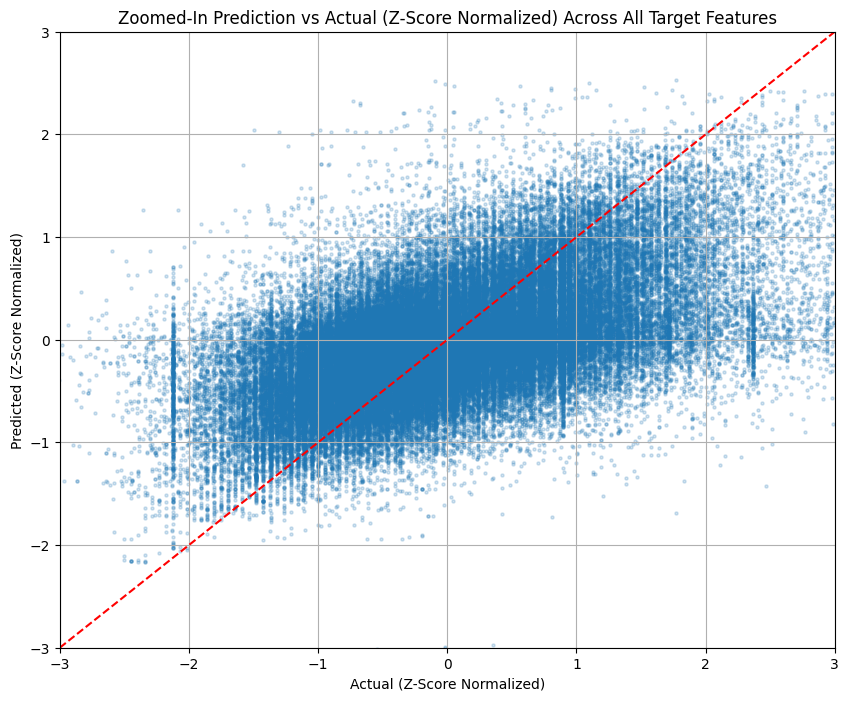

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure the model is in evaluation mode and on the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
trained_model.eval()
trained_model.to(device)

# Collect predictions and actuals from the test set
all_preds = []
all_tgts = []
all_masks = []

with torch.no_grad():
    for batch in test_loader:
        hist_data, _, forecast_tgt, forecast_mask = batch
        X, truth_time_steps, mask_hist, time_steps_to_predict, last_obs = hist_data

        # Move tensors to device
        X = X.to(device)
        truth_time_steps = truth_time_steps.to(device)
        mask_hist = mask_hist.to(device)
        time_steps_to_predict = time_steps_to_predict.to(device)
        last_obs = last_obs.to(device)
        forecast_tgt = forecast_tgt.to(device)
        forecast_mask = forecast_mask.to(device)

        # Get forecasts (temporal part only)
        _, forecasted, _, _ = trained_model(
            X, truth_time_steps, mask_hist, last_obs, future_timestamps=time_steps_to_predict
        )

        # Ensure we're only getting the temporal dimensions for target and mask
        tgt_temporal = forecast_tgt[:, :, STATIC_DIM:STATIC_DIM + TEMPORAL_DIM]
        mask_temporal = forecast_mask[:, :, STATIC_DIM:STATIC_DIM + TEMPORAL_DIM]

        if forecasted is not None:
            all_preds.append(forecasted.detach().cpu())
            all_tgts.append(tgt_temporal.detach().cpu())
            all_masks.append(mask_temporal.detach().cpu())

if len(all_preds) > 0:
    preds = torch.cat(all_preds, dim=0)
    tgts = torch.cat(all_tgts, dim=0)
    masks = torch.cat(all_masks, dim=0)

    preds_flat = preds.view(-1, preds.size(2))
    tgts_flat = tgts.view(-1, tgts.size(2))
    masks_flat = masks.view(-1, masks.size(2))

    # Filter out padded values using the mask
    preds_observed = preds_flat[masks_flat.bool()]
    tgts_observed = tgts_flat[masks_flat.bool()]

    if tgts_observed.numel() > 0: # Only plot if there are observed values
        preds_observed_np = preds_observed.cpu().numpy()
        tgts_observed_np = tgts_observed.cpu().numpy()

        # Calculate percentiles as in the user's snippet (though not used for plot limits in the end)
        min_val_tgt = np.percentile(tgts_observed_np, 1)
        max_val_tgt = np.percentile(tgts_observed_np, 99)
        min_val_pred = np.percentile(preds_observed_np, 1)
        max_val_pred = np.percentile(preds_observed_np, 99)

        plot_min_calc = min(min_val_tgt, min_val_pred)
        plot_max_calc = max(max_val_tgt, max_val_pred)

        print(f"Calculated Plot Min (1st percentile): {plot_min_calc:.4f}")
        print(f"Calculated Plot Max (99th percentile): {plot_max_calc:.4f}")

        plt.figure(figsize=(10, 8))
        plt.scatter(tgts_observed_np, preds_observed_np, alpha=0.2, s=5)
        plt.xlabel('Actual (Z-Score Normalized)')
        plt.ylabel('Predicted (Z-Score Normalized)')
        plt.title('Zoomed-In Prediction vs Actual (Z-Score Normalized) Across All Target Features')

        # Apply user-defined fixed limits for x and y axes
        plot_min_fixed = -3.0
        plot_max_fixed = 3.0
        plt.xlim(plot_min_fixed, plot_max_fixed)
        plt.ylim(plot_min_fixed, plot_max_fixed)

        # Add a line for perfect prediction using the new plot limits
        plt.plot([plot_min_fixed, plot_max_fixed], [plot_min_fixed, plot_max_fixed], 'r--')
        plt.grid(True)
        plt.show()
    else:
        print('No observed values to plot after filtering.')
else:
    print('No predictions generated for plotting.')

In [20]:
if history and 'val' in history and len(history['val']) > 0:
    last_val_metrics = history['val'][-1]
    if 'rmse' in last_val_metrics:
        print(f"Validation RMSE for the last epoch: {last_val_metrics['rmse']:.4f}")
    else:
        print("RMSE not found in the last validation epoch's metrics.")
else:
    print("No validation history available.")

Validation RMSE for the last epoch: 0.8054


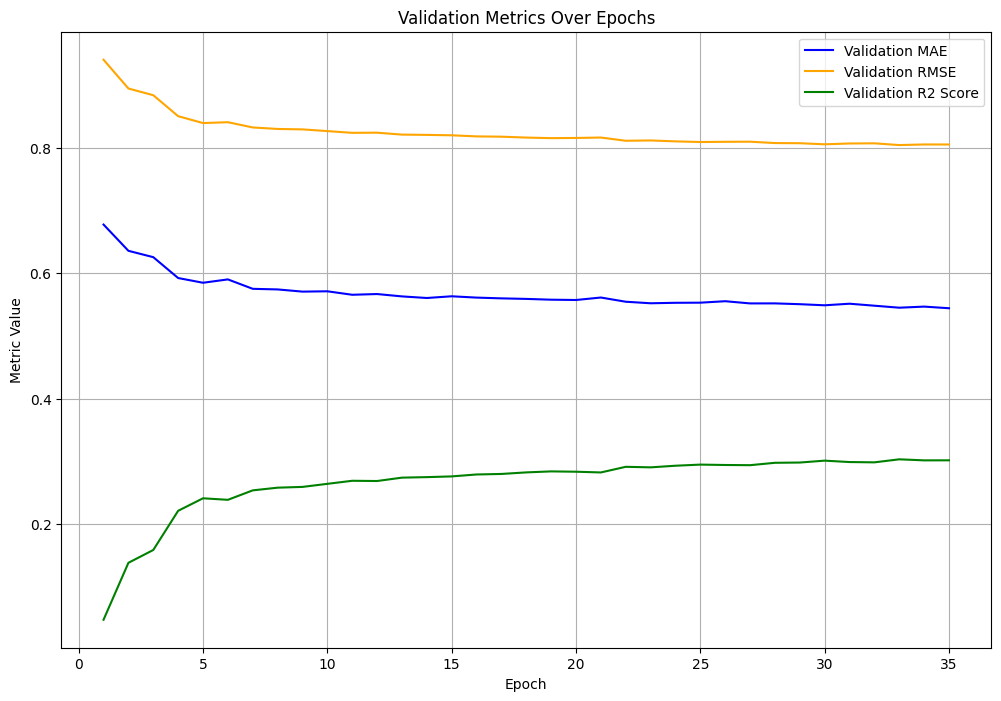

In [17]:
import matplotlib.pyplot as plt

# Extract metrics from validation history
val_mae = [h['mae'] for h in history['val'] if 'mae' in h]
val_rmse = [h['rmse'] for h in history['val'] if 'rmse' in h]
val_r2 = [h['r2'] for h in history['val'] if 'r2' in h]
epochs = range(1, len(val_mae) + 1)

# Plot Validation MAE, RMSE, and R2 Score on a single plot
plt.figure(figsize=(12, 8))

if len(val_mae) > 0:
    plt.plot(epochs, val_mae, label='Validation MAE', color='blue')
else:
    print("MAE data not available in history.")

if len(val_rmse) > 0:
    plt.plot(epochs, val_rmse, label='Validation RMSE', color='orange')
else:
    print("RMSE data not available in history.")

if len(val_r2) > 0:
    plt.plot(epochs, val_r2, label='Validation R2 Score', color='green')
else:
    print("R2 data not available in history.")

plt.title('Validation Metrics Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()

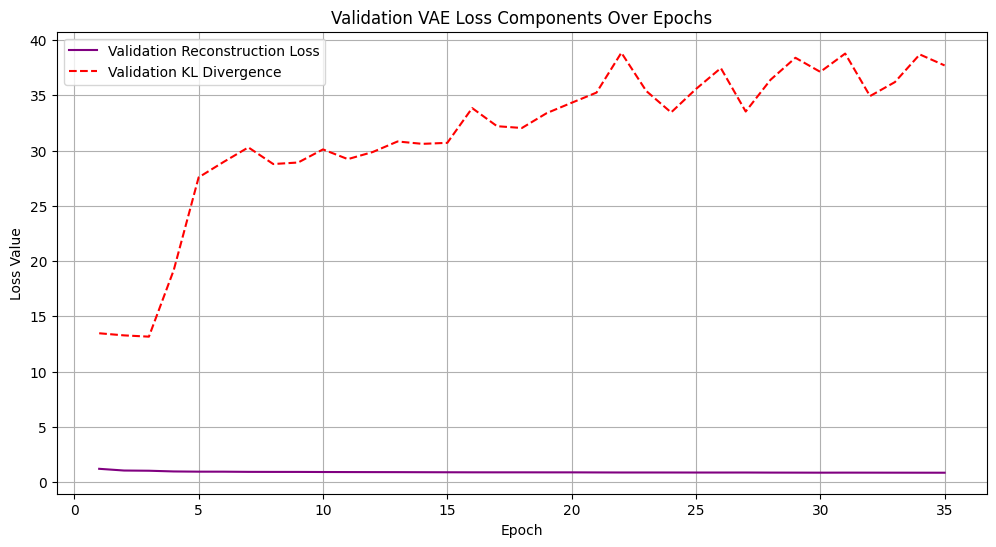

In [18]:
import matplotlib.pyplot as plt

# Extract VAE-specific losses from validation history
val_recon_loss = [h['recon_loss'] for h in history['val'] if 'recon_loss' in h]
val_kl_loss = [h['kl_loss'] for h in history['val'] if 'kl_loss' in h]
epochs = range(1, len(val_recon_loss) + 1)

# Plot Validation Reconstruction Loss and KL Divergence
if len(val_recon_loss) > 0 and len(val_kl_loss) > 0:
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, val_recon_loss, label='Validation Reconstruction Loss', color='purple')
    plt.plot(epochs, val_kl_loss, label='Validation KL Divergence', color='red', linestyle='--')
    plt.title('Validation VAE Loss Components Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("VAE loss components data not available in history.")

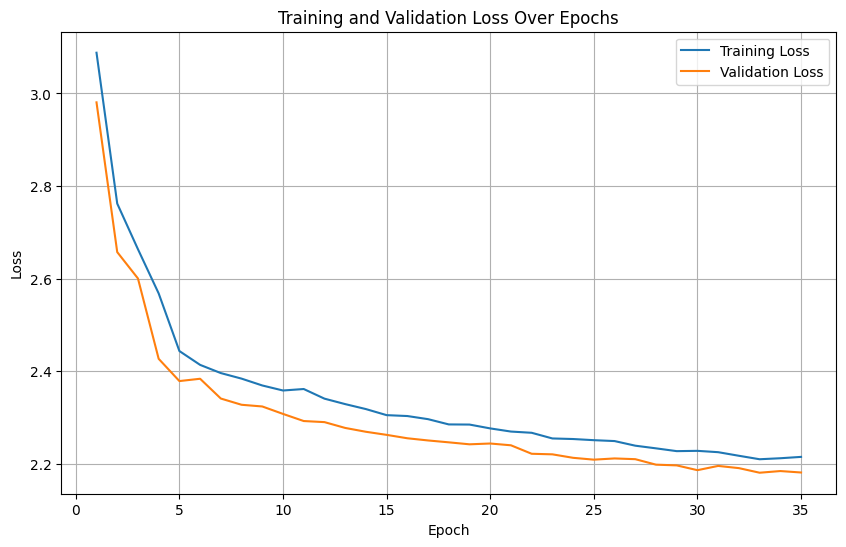

In [19]:
import matplotlib.pyplot as plt

# Extract training and validation losses
train_losses = [h['loss'] for h in history['train']]
val_losses = [h['loss'] for h in history['val']]
epcohs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epcohs, train_losses, label='Training Loss')
plt.plot(epcohs, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()